This Jupyter Notebook contains examples on how to calculate the SALEDI metric

# Initialization

In [1]:
# importing necessary libraries
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from src.configManager import ConfigManager
import xarray as xr

config = ConfigManager()

In [2]:
# code to set up matplotlib and seaborn styles

plt.style.use('default')

# Save the default rcParams to revert back if needed
dflt_rcParams = mpl.rcParams.copy()

# Change the default font
mpl.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial']})

# Increase the font size for better readability
mpl.rcParams.update({'font.size': 14, 
                     'axes.titlesize': 14,
                     'axes.titleweight': 'bold', 
                     'axes.labelsize': 12,
                     'axes.labelweight': 'bold',
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12, 
                     'legend.fontsize': 11})

# Remove the top and right spines for a cleaner look
mpl.rcParams.update({'axes.spines.right': False, 
                     'axes.spines.top': False,
                     'axes.spines.left': True,
                     'axes.spines.bottom': True})

# Add space between the plot and the title
mpl.rcParams.update({'axes.titlepad': 15})

# Set the figure size for all plots
mpl.rcParams.update({'figure.figsize': (10, 6)})

# Set the style for seaborn
sns.set_style("white")  # other options: "dark", "whitegrid", "darkgrid", "ticks"

## Functions

In [135]:
import powerlaw

In [136]:
def calculate_events_stats(dataset, event_threshold):
    # get a single dataframe merging customers_out, event_number_eaglei and maximum weather variables across all stations
    temp1 = dataset[['customers_out', 'event_number_eaglei']].to_dataframe().reset_index()
    temp2 = dataset[['tmpf', 'sknt', 'gust', 'p01i']].max(dim='station').to_dataframe().reset_index()
    merged_df = pd.merge(temp1, temp2, on='time')

    merged_df_non_zero = merged_df[merged_df['customers_out'] > 0].copy().reset_index()
    event_numbers = merged_df_non_zero.event_number_eaglei.value_counts()[merged_df_non_zero.event_number_eaglei.value_counts()>=event_threshold].index.tolist()
    
    # import the function to calculate EAGLEi event stats
    from src.eaglei_modules.eagleiEventProcessing import get_eaglei_event_stats
    events_stats = get_eaglei_event_stats(merged_df_non_zero, event_numbers, event_method='eaglei', timestamp_column='time')

    # # append weather stats to the events_stats dataframe
    # weather_stats_list = []
    # for event_num in event_numbers:
    #     event_data = merged_df_non_zero[merged_df_non_zero['event_number_eaglei'] == event_num]
    #     weather_stats = {
    #         'event_number': event_num,
    #         'max_sknt': event_data['sknt'].max(),
    #         'min_sknt': event_data['sknt'].min(),
    #         'avg_sknt': event_data['sknt'].mean(),

    #         'max_gust': event_data['gust'].max(),
    #         'min_gust': event_data['gust'].min(),
    #         'avg_gust': event_data['gust'].mean(),

    #         'max_tmpf': event_data['tmpf'].max(),
    #         'min_tmpf': event_data['tmpf'].min(),
    #         'avg_tmpf': event_data['tmpf'].mean(),
            
    #         'total_p01i': event_data['p01i'].sum(),
    #         'max_p01i': event_data['p01i'].max(),
    #         'avg_p01i': event_data['p01i'].mean()
    #     }
    #     weather_stats_list.append(weather_stats)
    # weather_stats_df = pd.DataFrame(weather_stats_list)
    # events_stats = pd.merge(events_stats, weather_stats_df, on='event_number', how='left')

    return events_stats

In [137]:
def calculateSALEDI(df, m_large, desired_RSE = 0.1):
    # check if the df has the necessary columns
    if not {'start_time', 'end_time', 'customer_hours_normalized'}.issubset(df.columns):
        raise ValueError("DataFrame must contain 'start_time', 'end_time', and 'customer_hours_normalized' columns.")
    
    from dateutil.relativedelta import relativedelta
    import numpy as np
    
    min_date = df.start_time.min()
    max_date = df.end_time.max()
    n_seconds_all = (max_date - min_date).total_seconds()
    f_all_large_secs = ((df['customer_hours_normalized'] >= m_large).sum()) / n_seconds_all
    n_large = 2/(desired_RSE**2)
    n_seconds = n_large/f_all_large_secs

    # create date ranges
    date_ranges = []
    while(True):
        next_date = max_date - relativedelta(seconds=int(n_seconds))
        if next_date < min_date:
            break
        date_ranges.append((next_date, max_date))
        max_date = max_date - relativedelta(years=1)

    def helperFuncSaledi(date_range):
        range_start = date_range[0]
        range_end = date_range[1]
        nYears = (range_end - range_start).days / 365.2425
        selectedData = df[(df['start_time'] >= range_start) & (df['start_time'] <= range_end) & (df['customer_hours_normalized'] >= m_large)]
        cmiValues = selectedData['customer_hours_normalized'].values
        cmiValues = cmiValues[cmiValues > 0]  # filter out non-positive values to avoid log(0) issues
        logCMI = cmiValues / m_large
        logCMI = np.log(logCMI)
        saledi = sum(logCMI) / nYears
        return float(saledi)

    def getYearFromDateRange(date_range):
        y = date_range[1].year
        # find the difference from the end date to the first day of the same year
        diff = date_range[1] - pd.Timestamp(year=date_range[1].year, month=1, day=1)
        # if the end date is in the first half of the year, assign it to the previous year
        if diff.days < 182:  
            y = y - 1
        return y

    salediByYear = [(getYearFromDateRange(date_range), helperFuncSaledi(date_range)) for date_range in date_ranges]
    return salediByYear

In [174]:
def calculate_county_saledi(state, county, start_year, end_year, config=config, desired_RSE=0.1, debug=False, plot=False):
    # Load the dataset
    ds_merged = xr.open_dataset(os.path.join(
        config.get("data_paths.merged_data_dir"),
        state,
        config.get("file_patterns.merged_file_pattern").format(
            state=state,
            county=county,
            start=start_year,
            end=end_year
        )
    ))  

    total_customers = ds_merged.attrs['total_county_customers']
    event_customer_threshold = int(ds_merged.attrs['event_customer_threshold'])

    if debug:
        print(f"Total customers in {county} County, {state}: {total_customers}")
        print(f"Event customer threshold: {event_customer_threshold}")

    # create a dataframe of customers_out and event_number_eaglei from the xarray dataset
    outage_df = ds_merged[['customers_out', 'event_number_eaglei']].to_dataframe().reset_index()
    if debug:
        print(f"Size of the outage dataframe: {outage_df.shape}")
    
    # keep only rows where customers_out > 0
    outage_df = outage_df[outage_df['customers_out'] > 0]
    if debug:
        print(f"Size of the outage dataframe after filtering customers_out > 0: {outage_df.shape}")

    # Total number of outage events
    if debug:
        print(f"Total number of outage events: {outage_df['event_number_eaglei'].nunique()}")
    
    # Total number of outage events, excluding the ones that don't meet the customers_out threshold
    customers_out_threshold = config.get('data_cleaning_parameters')['events_customer_threshold']
    if debug:
        print(f"Total number of outage events (customers_out > {customers_out_threshold}): {outage_df[outage_df['customers_out'] >= customers_out_threshold]['event_number_eaglei'].nunique()}")
    
    events_stats = calculate_events_stats(ds_merged, event_threshold=event_customer_threshold)
    events_stats['customer_hours_normalized'] = events_stats['customer_hours'] / total_customers

    # fit a power law distribution to the event_customer_hours_normalized data
    fit = powerlaw.Fit(events_stats['customer_hours_normalized'].values)
    alpha = fit.power_law.alpha-1  # subtract 1 to get the exponent for the pdf instead of the ccdf
    mLarge = fit.power_law.xmin
    if debug:
        print(f"Estimated power law alpha: {alpha}")
        print(f"Estimated power law xmin: {mLarge}")

    n_year_all = (events_stats['start_time'].max() - events_stats['start_time'].min()).days / 365.2425
    n_large_events = (events_stats['customer_hours_normalized'] >= mLarge).sum()
    f_all_large = n_large_events / n_year_all
    n_large = 2/(desired_RSE**2)
    n_year = n_large/f_all_large

    if debug:
        print(f"Total number of years in the dataset: {n_year_all:.2f}")
        print(f"Total number of large events: {n_large_events}")
        print(f"f_all_large: {f_all_large:.2f} events per year")
        print(f"Exact n_year to get a desired RSE of {desired_RSE} (and corresponding n_large = {n_large:.1f} and RSE_ALE = {(1/n_large)**0.5:.2f}) is: {n_year:.2f}")

    
    yearly_saledi = calculateSALEDI(events_stats, mLarge, desired_RSE=desired_RSE)

    if plot:
        # create an empirical ccdf of event_customer_hours_normalized
        sns.ecdfplot(data=events_stats, x='customer_hours_normalized', complementary=True, log_scale=True, color='red')
        # add a vertical line to show the estimated power law xmin
        plt.axvline(mLarge, color='blue', linestyle='--', label=f'Mlarge: {mLarge:.4f}')
        plt.legend()
        plt.xlabel('Event Customer-Hours (Normalized by Total Customers)')
        plt.ylabel('CCDF')
        plt.yscale('log')
        plt.title('Empirical CCDF of Event Customer-Hours (Log-Log Scale) for {} County, {}'.format(county, state))
        plt.show()

        plt.figure(figsize=(10, 6))
        plt.plot([x[0] for x in yearly_saledi], [x[1] for x in yearly_saledi], marker='o')
        plt.title('Yearly SALEDI Values for {} County, {}'.format(county, state))
        plt.xlabel('Year')
        plt.ylabel('SALEDI')
        plt.locator_params(axis='x', integer=True)
        plt.grid()
        plt.show()

    ds_merged.close()

    return n_year, yearly_saledi

# SALEDI Metric

In [169]:
# state = config.get('processing_parameters')['state']
# county = config.get('processing_parameters')['county']
# start_year = config.get('processing_parameters')['start_year']
# end_year = config.get('processing_parameters')['end_year']

state = 'Illinois'
county = 'Cook'
start_year = 2014
end_year = 2024

ds_merged = xr.open_dataset(os.path.join(
    config.get("data_paths.merged_data_dir"),
    state,
    config.get("file_patterns.merged_file_pattern").format(
        state=state,
        county=county,
        start=start_year,
        end=end_year
    )
))  

In [175]:
# check the different details of the dataset in an interactive viewer
ds_merged

<xarray.Dataset> Size: 40MB
Dimensions:              (time: 385728, station: 4)
Coordinates:
  * time                 (time) datetime64[ns] 3MB 2014-01-01 ... 2024-12-31T...
  * station              (station) <U3 48B '06C' 'IGQ' 'MDW' 'PWK'
    lat                  (station) <U7 112B ...
    lon                  (station) <U8 128B ...
Data variables:
    tmpf                 (time, station) float32 6MB ...
    sknt                 (time, station) float32 6MB ...
    gust                 (time, station) float32 6MB ...
    p01i                 (time, station) float32 6MB ...
    poccurence           (time, station) float32 6MB ...
    customers_out        (time) int64 3MB ...
    event_number_eaglei  (time) int64 3MB ...
Attributes:
    title:                     Merged Weather and Outage Data for Cook, Illin...
    description:               This dataset contains weather data from multip...
    state:                     Illinois
    county:                    Cook
    start_year:                2014
    end_year:                  2024
    creation_date:             2026-01-28 13:12:59
    temporal_resolution:       15 minutes
    county_fips_code:          17031
    total_county_customers:    2395489
    event_customer_threshold:  30

In [176]:
total_customers = ds_merged.attrs['total_county_customers']
print(f"Total customers in {county} County, {state}: {total_customers}")

Total customers in Cook County, Illinois: 2395489


In [177]:
# create a dataframe of customers_out and event_number_eaglei from the xarray dataset
outage_df = ds_merged[['customers_out', 'event_number_eaglei']].to_dataframe().reset_index()
print(f"Size of the outage dataframe: {outage_df.shape}")
# keep only rows where customers_out > 0
outage_df = outage_df[outage_df['customers_out'] > 0]
print(f"Size of the outage dataframe after filtering customers_out > 0: {outage_df.shape}")

Size of the outage dataframe: (385728, 3)
Size of the outage dataframe after filtering customers_out > 0: (341243, 3)


In [178]:
outage_df.head()

,time,customers_out,event_number_eaglei
29200,2014-11-01 04:00:00,4231,1
29201,2014-11-01 04:15:00,4231,1
29202,2014-11-01 04:30:00,4017,1
29203,2014-11-01 04:45:00,4017,1
29204,2014-11-01 05:00:00,3975,1


In [179]:
# Total number of outage events
print(f"Total number of outage events: {outage_df['event_number_eaglei'].nunique()}")
# Total number of outage events, excluding the ones that don't meet the customers_out threshold
customers_out_threshold = config.get('data_cleaning_parameters')['events_customer_threshold']
print(f"Total number of outage events (customers_out > {customers_out_threshold}): {outage_df[outage_df['customers_out'] >= customers_out_threshold]['event_number_eaglei'].nunique()}")

Total number of outage events: 3681
Total number of outage events (customers_out > 30): 2898


In [180]:
events_stats = calculate_events_stats(ds_merged, event_threshold=30)

In [181]:
events_stats

,event_number,start_time,end_time,duration_hours,max_customers_out,total_customers_out,num_outages,num_restores,customer_hours,counties_affected
0,712,2016-08-12 20:45:00,2016-10-08 17:45:00,1365.00,108,270,5,5,73764.00,None
1,715,2016-11-06 17:15:00,2016-12-31 00:15:00,1303.00,54,54,1,1,70362.00,None
2,710,2016-06-24 09:45:00,2016-08-11 14:15:00,1156.50,850,1519,21,20,65567.25,None
3,716,2017-01-01 00:00:00,2017-02-04 06:00:00,822.00,476,1029,29,28,45108.25,None
4,713,2016-10-08 22:30:00,2016-11-05 09:45:00,659.25,54,54,1,1,35599.50,None
...,...,...,...,...,...,...,...,...,...,...
1831,721,2017-02-05 14:00:00,2017-02-05 21:30:00,7.50,47,64,5,9,199.50,None
1832,990,2017-08-27 12:00:00,2017-08-27 19:30:00,7.50,439,577,6,7,1370.00,None
1833,1734,2019-04-14 12:00:00,2019-04-14 19:30:00,7.50,1842,2063,9,5,2574.75,None
1834,174,2015-03-08 13:00:00,2015-03-08 20:30:00,7.50,102,104,6,8,167.50,None


In [182]:
events_stats['customer_hours_normalized'] = events_stats['customer_hours'] / total_customers

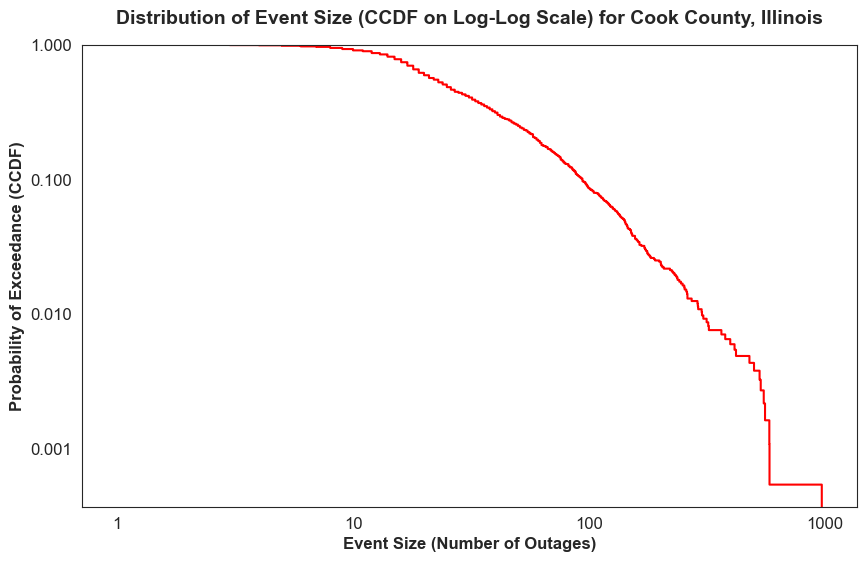

In [ ]:
from matplotlib.ticker import ScalarFormatter
sns.ecdfplot(data=events_stats, x='num_outages', complementary=True, log_scale=True, color='red')
plt.xlabel('Event Size (Number of Outages)')
plt.ylabel('Probability of Exceedance (CCDF)')
plt.yscale('log')
plt.title('Distribution of Event Size (CCDF on Log-Log Scale) for {} County, {}'.format(county, state))
# change the x-axis and y-axis ticks to be more readable
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.show()

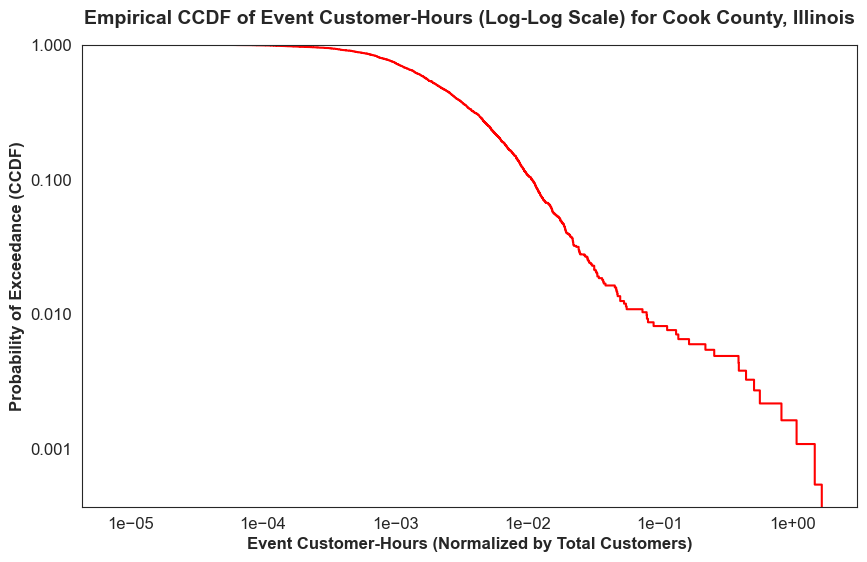

In [ ]:
# create an empirical ccdf of event_customer_hours_normalized
from matplotlib.ticker import ScalarFormatter

sns.ecdfplot(data=events_stats, x='customer_hours_normalized', complementary=True, log_scale=True, color='red')
plt.xlabel('Event Customer-Hours (Normalized by Total Customers)')
plt.ylabel('Probability of Exceedance (CCDF)')
plt.yscale('log')
plt.title('Empirical CCDF of Event Customer-Hours (Log-Log Scale) for {} County, {}'.format(county, state))
# change the x-axis and y-axis ticks to be more readable
plt.gca().xaxis.set_major_formatter('{x:.0e}')
plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.show()

In [184]:
# use the powerlaw package to fit a power law distribution to the event_customer_hours_normalized data
import powerlaw
fit = powerlaw.Fit(events_stats['customer_hours_normalized'].values)
alpha = fit.power_law.alpha-1  # subtract 1 to get the exponent for the pdf instead of the ccdf
mLarge = fit.power_law.xmin
print(f"Estimated power law alpha: {alpha}")
print(f"Estimated power law xmin: {mLarge}")

Calculating best minimal value for power law fit
Estimated power law alpha: 1.1918109332131461
Estimated power law xmin: 0.004290981924776111


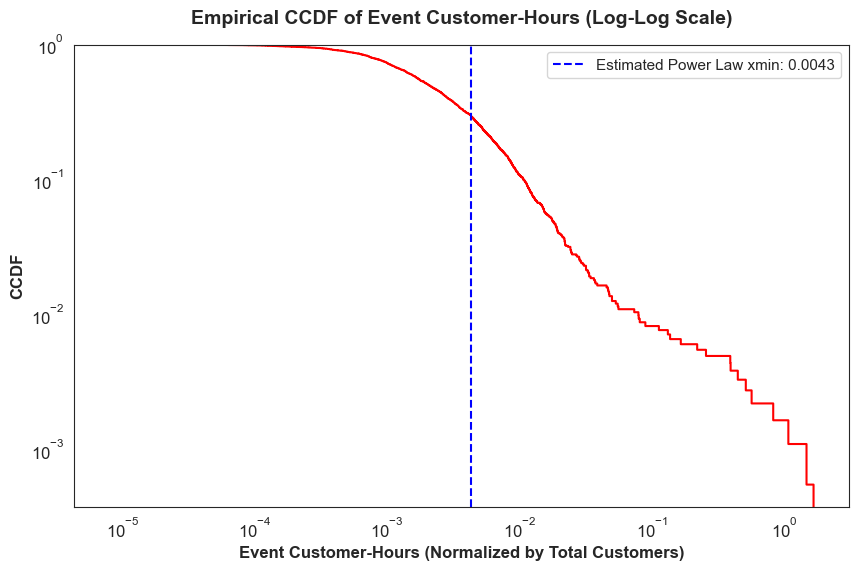

In [185]:
# create an empirical ccdf of event_customer_hours_normalized
sns.ecdfplot(data=events_stats, x='customer_hours_normalized', complementary=True, log_scale=True, color='red')
# add a vertical line to show the estimated power law xmin
plt.axvline(mLarge, color='blue', linestyle='--', label=f'Estimated Power Law xmin: {mLarge:.4f}')
plt.legend()
plt.xlabel('Event Customer-Hours (Normalized by Total Customers)')
plt.ylabel('CCDF')
plt.yscale('log')
plt.title('Empirical CCDF of Event Customer-Hours (Log-Log Scale)')
plt.show()

<Axes: xlabel='start_time'>

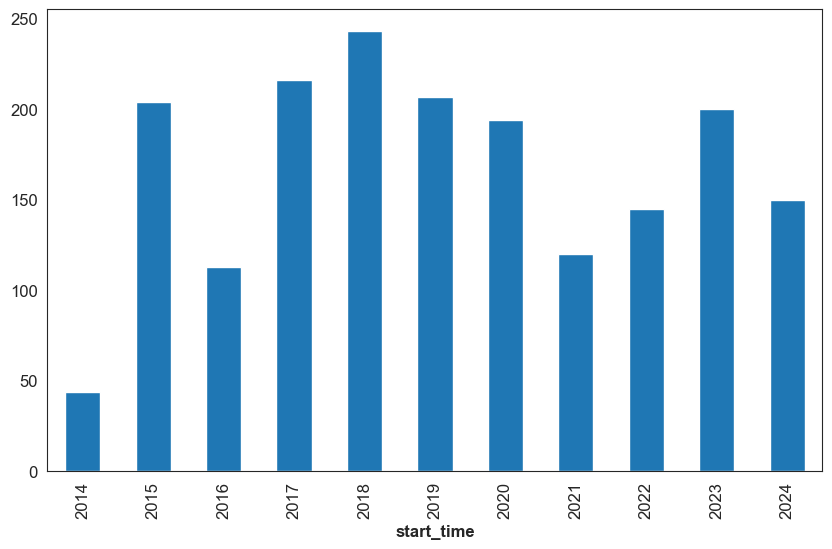

In [186]:
events_stats.start_time.dt.year.value_counts().sort_index().plot(kind='bar')

In [189]:
n_year_all = (events_stats.start_time.max() - events_stats.start_time.min()).days / 365.2425

f_all_large = ((events_stats['customer_hours_normalized'] >= mLarge).sum()) / n_year_all
desiredRSE = 0.1
n_large = 2/(desiredRSE**2)
n_year = n_large/f_all_large

print(f"Total number of years in the dataset: {n_year_all:.2f}")
print(f"f_all_large: {f_all_large:.2f} events per year")
print(f"Exact n_year to get a desired RSE of {desiredRSE} (and corresponding n_large = {n_large:.1f} and RSE_ALE = {(1/n_large)**0.5:.2f}) is: {n_year:.2f}")

Total number of years in the dataset: 10.16
f_all_large: 54.12 events per year
Exact n_year to get a desired RSE of 0.1 (and corresponding n_large = 200.0 and RSE_ALE = 0.07) is: 3.70


In [190]:
yearly_saledi_cook = calculateSALEDI(events_stats, mLarge)

In [191]:
yearly_saledi_cook

[(2024, 47.06822501864671),
 (2023, 50.67878293892222),
 (2022, 54.09073742959035),
 (2021, 57.995623471547574),
 (2020, 50.67582231335275),
 (2019, 42.85064633337779),
 (2018, 44.91109865021238)]

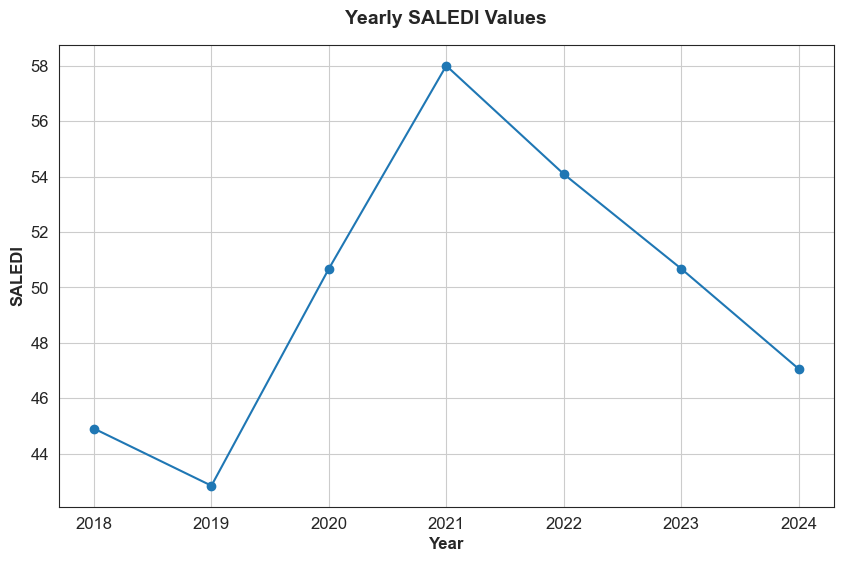

In [192]:
plt.figure(figsize=(10, 6))
plt.plot([x[0] for x in yearly_saledi_cook], [x[1] for x in yearly_saledi_cook], marker='o')
plt.title('Yearly SALEDI Values')
plt.xlabel('Year')
plt.ylabel('SALEDI')
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.locator_params(axis='x', integer=True)
plt.grid()
plt.show()

In [194]:
yearly_saledi_dupage = calculate_county_saledi('Illinois', 'DuPage', 2014, 2024, debug=False, plot=False)

Calculating best minimal value for power law fit


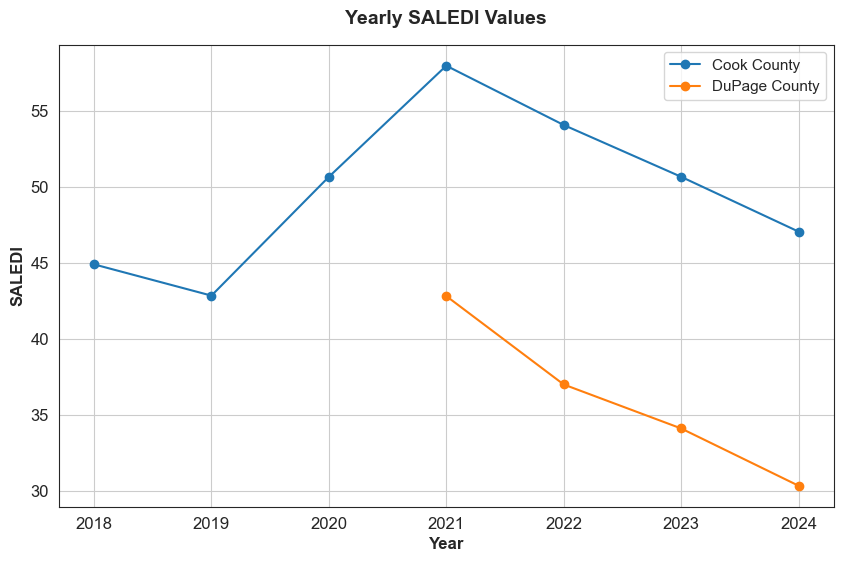

In [195]:
plt.figure(figsize=(10, 6))
plt.plot([x[0] for x in yearly_saledi_cook], [x[1] for x in yearly_saledi_cook], marker='o', label='Cook County')
plt.plot([x[0] for x in yearly_saledi_dupage[1]], [x[1] for x in yearly_saledi_dupage[1]], marker='o', label='DuPage County')
plt.legend()
plt.title('Yearly SALEDI Values')
plt.xlabel('Year')
plt.ylabel('SALEDI')
# plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.locator_params(axis='x', integer=True)
plt.grid()
plt.show()